# Week 4 Lab 
## Topics: Regression concepts, model fitting, prediction. 

Problems: (a) Implement simple linear regression on a dataset.

 (b) Compute R²,
MSE, and visualize regression line

( c ) Predict values for new data points. 

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split

In [7]:
df = pd.read_csv('simple_house-prices.csv')
print(df.head())
print(df.columns)
print(df.info())
print(df.shape)
print(df.describe())

   area    price
0  1360   463036
1  4272  1140770
2  3592   871438
3   966   320595
4  4926  1164933
Index(['area', 'price'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   area    7000 non-null   int64
 1   price   7000 non-null   int64
dtypes: int64(2)
memory usage: 109.5 KB
None
(7000, 2)
              area         price
count  7000.000000  7.000000e+03
mean   2764.204143  7.897345e+05
std    1289.509444  2.869134e+05
min     501.000000  1.683800e+05
25%    1631.000000  5.510930e+05
50%    2781.000000  7.885235e+05
75%    3874.000000  1.029324e+06
max    5000.000000  1.419349e+06


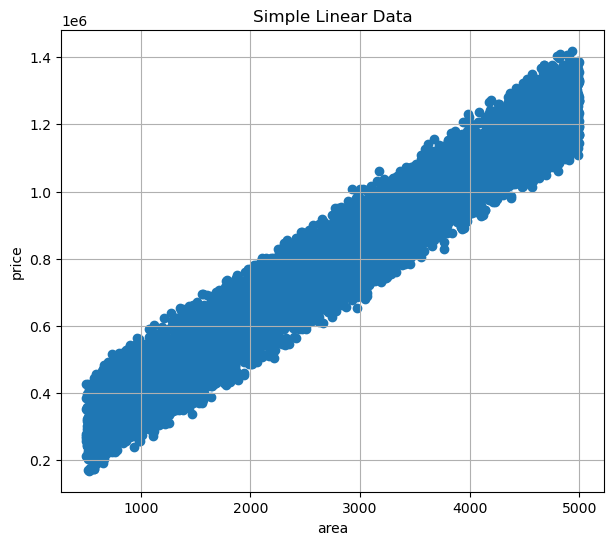

,area,price
0,1360,463036
1,4272,1140770
2,3592,871438
3,966,320595
4,4926,1164933


In [8]:
plt.figure(figsize = (7,6))
plt.scatter(df['area'],df['price'])
plt.title('Simple Linear Data')
plt.xlabel('area')
plt.ylabel('price')
plt.grid()
plt.show()

df.head()

# (a) Implement simple linear regression on a dataset.

In [9]:
#normalize data here 
price_min = df['price'].min()   #Save min and max before normalizing data for deormalization
price_max = df['price'].max()
area_min = df['area'].min()
area_max = df['area'].max()
print(price_min,price_max)
def normalize(df,col):
    x_min = df[col].min()
    x_max = df[col].max()
    return (df[col] - x_min) / (x_max - x_min) 
df['area'] = normalize(df,'area')
df['price'] = normalize(df,'price')
print(df.head())

x =  df['area']
y = df['price']
x_train, x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)

168380 1419349
       area     price
0  0.190931  0.235542
1  0.838186  0.777309
2  0.687042  0.562011
3  0.103356  0.121678
4  0.983552  0.796625


In [10]:
#denormalization of data 
def denormalize_price(normalized_val, p_min, p_max):
    return normalized_val * p_max 

In [11]:
#prediction function
def predict(m,c,x):
    return np.dot(m,x) + c

In [12]:
def calculate_cost(y, y_hat):
    n = len(y)
    error = (y - y_hat)**2
    return np.sum(error) / n

In [13]:
#initialize parameters 
m = 0
c = 0
lr = 0.1

#Model fitting using gradient descent 
def gradient_descent(x, y, m, c, lr):
    n = len(y)
    y_hat = predict(m, c, x)

    dm = (-2/n) * np.sum(x * (y - y_hat))
    dc = (-2/n) * np.sum(y - y_hat)
    
    # Update m and c
    m = m - (lr * dm)
    c = c - (lr * dc)
    
    return m, c,y_hat

In [14]:
for i in range(400):
    m, c,y_hat = gradient_descent(x_train, y_train, m, c, lr)
    
    current_loss = calculate_cost(y_train, y_hat)
    
    # Print progress every 100 iterations
    if i % 100 == 0:
        print(f"Iteration {i}: Cost = {current_loss:.5f}")

print(f"\nFinal Weights: m = {m:.4f}, c = {c:.4f}")

Iteration 0: Cost = 0.29922
Iteration 100: Cost = 0.00554
Iteration 200: Cost = 0.00376
Iteration 300: Cost = 0.00363

Final Weights: m = 0.7688, c = 0.1098


In [15]:
def price(user_area):
    #Normalize the input area!
    normalized_input = (user_area - area_min) / (area_max - area_min)
    
    #Predict
    normalized_price = predict(m, c, normalized_input) # --> number between 0 and 1
    
    #Denormalize the price back to indian rupees 
    real_price = normalized_price * (price_max - price_min) + price_min
    
    return real_price

# (b)  Compute R², MSE, and visualize regression line

In [16]:
# Compute MSE (Mean Squared Error )
def compute_MSE(x_test):
    y_pred = predict(m, c, x_test)
    # Formula: Average of (Actual - Predicted)^2
    return np.mean((y_test - y_pred)**2)

mse = compute_MSE(x_test)
print(f"Error--> {mse}")

Error--> 0.0036548995970519154


In [17]:
# Compute r2 score 
def compute_r2(y_test):
    # Formula: 1 - (Sum of Squared Residuals / Total Sum of Squares)
    y_pred = predict(m, c, x_test)
    ss_res = np.sum((y_test - y_pred)**2)
    ss_tot = np.sum((y_test - np.mean(y_test))**2)
    return 1 - (ss_res / ss_tot)

r2 = compute_r2(y_test)
print(f"Accuracy--> {r2}")

Accuracy--> 0.932684111474983


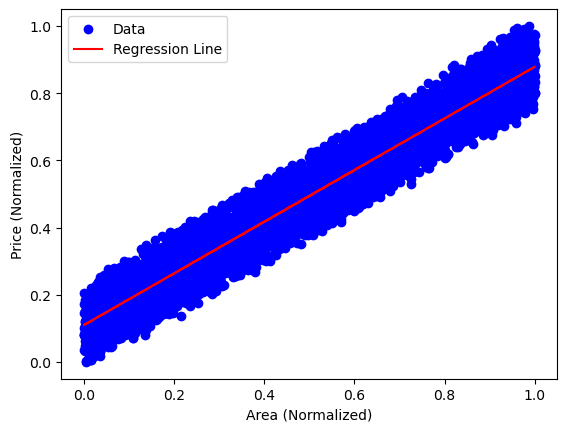

In [45]:
# visualize regression line 
plt.scatter(x_train, y_train, color='blue', label='Data')
reg_line = m * x_train + c
plt.plot(x_train, reg_line, color='red', label='Regression Line')
plt.xlabel('Area (Normalized)')
plt.ylabel('Price (Normalized)')
plt.legend()
plt.show()

# (c) Predict values for new data points

In [43]:
area = int(input("Enter area of a house in square feet for prediction"))
rupees = price(area)
print(f"price of a house in indian rupees = {rupees } ")

Enter area of a house in square feet for prediction -930


price of a house in indian rupees = -175.7670087882434 
